# Resume Matcher — Снятие метрик с тестовых данных

**Точная копия бэкенда проекта.** Код взят из реальных файлов:
- `ranker.py` → `ResumeRanker` (intfloat/e5-large-v2)
- `judge.py` → `llm_judge` с точным промптом и парсингом JSON
- `custom_transformers.py` → `MyTransformer` (фича = llm × semantic)
- `model_best_resume_matcher.pkl` → Pipeline: MyTransformer → StandardScaler → SGDRegressor

**Логика метрик (по обсуждению команды):**
- Задача — **не пропустить годного кандидата** → главная метрика **Recall**
- Порог истинно положительного решения: `final_score >= 80`
- `ideal` + `medium` = релевантные (positive), `miss` = нерелевантные (negative)

## Шаг 1 — Установка зависимостей

In [ ]:
!pip install -q sentence-transformers pdfplumber python-docx huggingface_hub scikit-learn joblib
print('OK')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 1.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.4/68.4 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 49.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.0/253.0 kB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 43.8 MB/s eta 0:00:00
OK


## Шаг 2 — Загрузка файлов

Загрузи **два файла**:
1. `resume_matcher_dataset_v2.zip` — архив с резюме и вакансиями
2. `model_best_resume_matcher.pkl` — бинарник модели из проекта

In [ ]:
from google.colab import files
import zipfile, os

print('Загрузи ZIP с датасетом И файл model_best_resume_matcher.pkl ...')
uploaded = files.upload()

for fname in uploaded:
    if fname.endswith('.zip'):
        with zipfile.ZipFile(fname, 'r') as z:
            z.extractall('dataset')
        print(f'Распаковано: {fname}')
    elif fname.endswith('.pkl'):
        print(f'Модель загружена: {fname}')

# Найти корень датасета автоматически
DATASET_ROOT = None
for root, dirs, fs in os.walk('dataset'):
    if any(f.endswith('.pdf') for f in fs) and any(d.startswith('vac') for d in dirs):
        DATASET_ROOT = root
        break

MODEL_PATH = 'model_best_resume_matcher.pkl'
assert DATASET_ROOT, 'Датасет не найден!'
assert os.path.exists(MODEL_PATH), 'Не найден model_best_resume_matcher.pkl!'
print(f'Датасет: {DATASET_ROOT}')
print('Всё готово!')

Загрузи ZIP с датасетом И файл model_best_resume_matcher.pkl ...


Saving model_best_resume_matcher.pkl to model_best_resume_matcher.pkl
Saving resume_matcher_dataset.zip to resume_matcher_dataset.zip
Модель загружена: model_best_resume_matcher.pkl
Распаковано: resume_matcher_dataset.zip
Датасет: dataset/resume_matcher_dataset_v2
Всё готово!


## Шаг 3 — Hugging Face токен

1. Зайди на https://huggingface.co/settings/tokens
2. Нажми **New token** → тип **Read** → скопируй
3. Вставь ниже

In [ ]:
from getpass import getpass
HF_TOKEN = getpass('HF токен: ')
print('Токен сохранён')

HF токен: ··········
Токен сохранён


## Шаг 4 — Загрузка кода бэкенда (точные копии файлов проекта)

In [ ]:
# ── custom_transformers.py — ТОЧНАЯ КОПИЯ ─────────────────────────────
from sklearn.base import TransformerMixin, BaseEstimator
import numpy as np

class MyTransformer(TransformerMixin, BaseEstimator):
    '''Шаблон кастомного трансформера'''
    def __init__(self):
        pass

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        # Создаём новый столбец как произведение первых двух: llm_score * semantic_score
        new_column = X[:, 0] * X[:, 1]
        new_column = new_column.reshape(-1, 1)
        X = np.append(X, new_column, axis=1)
        return X

# Обязательно — иначе joblib не загрузит pickle
import __main__
__main__.MyTransformer = MyTransformer
print('custom_transformers.py OK')

custom_transformers.py OK


In [ ]:
# ── ranker.py — ТОЧНАЯ КОПИЯ ──────────────────────────────────────────
from sentence_transformers import SentenceTransformer, util

class ResumeRanker:
    def __init__(self, model_name='intfloat/e5-large-v2'):
        self.device = 'cpu'
        self.model = SentenceTransformer(model_name, device=self.device)
        print(f'Модель эмбеддингов загружена на: {self.device}')

    def get_embeddings(self, text_list):
        processed_texts = [f'passage: {t}' for t in text_list]
        return self.model.encode(processed_texts, convert_to_tensor=True)

    def calculate_similarity(self, vacancy_text, resume_embeddings):
        query_text = f'query: {vacancy_text}'
        query_embedding = self.model.encode(query_text, convert_to_tensor=True)
        cosine_scores = util.cos_sim(query_embedding, resume_embeddings)[0]
        return cosine_scores.tolist()

print('Загружаем ResumeRanker (e5-large-v2, ~1.2GB)...')
ranker = ResumeRanker()
print('ranker.py OK')

Загружаем ResumeRanker (e5-large-v2, ~1.2GB)...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/387 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/57.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/201 [00:00<?, ?B/s]

Модель эмбеддингов загружена на: cpu
ranker.py OK


In [ ]:
# ── judge.py — ТОЧНАЯ КОПИЯ ───────────────────────────────────────────
# Единственное отличие: вместо requests к VLLM_URL используем HF Inference API
# Промпт, парсинг JSON, обработка ошибок — идентичны оригиналу
import json, re, logging
from typing import Any
from huggingface_hub import InferenceClient

logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

LLM_MODEL = 'Qwen/Qwen2.5-72B-Instruct'  # та же модель qwen2.5 что в проекте
hf_client = InferenceClient(token='')

def _extract_json_object(text: str) -> dict[str, Any]:
    """Точная копия из judge.py"""
    raw = (text or '').strip()
    if not raw:
        raise ValueError('пустой content от модели')
    fenced = re.search(r'```(?:json)?\s*([\s\S]*?)```', raw, re.IGNORECASE)
    if fenced:
        raw = fenced.group(1).strip()
    try:
        out = json.loads(raw)
        if isinstance(out, dict):
            return out
    except json.JSONDecodeError:
        pass
    start, end = raw.find('{'), raw.rfind('}')
    if start != -1 and end > start:
        return json.loads(raw[start:end + 1])
    raise ValueError(f'не удалось извлечь JSON: {raw[:400]!r}')


def llm_judge(vacancy_description: str, resume_text: str) -> dict[str, Any]:
    """Точная копия промпта и логики из judge.py"""
    prompt = f"""
    Оцени соответствие кандидата вакансии по шкале от 0 до 100.
    Вакансия: {vacancy_description[:1000]}
    Резюме: {resume_text[:2000]}

    Ответь строго одним JSON-объектом без пояснений до и после: {{"score": число, "reasoning": "краткое обоснование"}}
    """
    try:
        response = hf_client.chat.completions.create(
            model=LLM_MODEL,
            messages=[
                {'role': 'system', 'content': 'You are a professional HR recruiter.'},
                {'role': 'user', 'content': prompt},
            ],
            max_tokens=512,
            temperature=0.1,
        )
        content = response.choices[0].message.content
        if isinstance(content, list):
            content = ''.join(
                b.get('text', '') for b in content
                if isinstance(b, dict) and b.get('type') == 'text'
            )
        if not (isinstance(content, str) and content.strip()):
            raise ValueError('пустой content от модели')
        parsed = _extract_json_object(content)
        return {'score': parsed.get('score', 0), 'reasoning': parsed.get('reasoning', '')}
    except Exception as e:
        logger.exception('Ошибка LLM-судьи: %s', e)
        return {'score': 0, 'reasoning': f'Ошибка обработки: {e}'}

print('judge.py OK')

judge.py OK


In [ ]:
# ── parser.py — ТОЧНАЯ КОПИЯ ──────────────────────────────────────────
import pdfplumber

def extract_text_from_pdf(pdf_path: str) -> str:
    text = ''
    with pdfplumber.open(pdf_path) as pdf:
        for page in pdf.pages:
            page_text = page.extract_text()
            if page_text:
                text += page_text
    return text

print('parser.py OK')

parser.py OK


In [ ]:
# ── model_best_resume_matcher.pkl — загрузка ──────────────────────────
# Pipeline: MyTransformer → StandardScaler → SGDRegressor
# Вход: [[llm_score, semantic_score]]  (semantic в диапазоне 0..1 косинус)
import joblib

loaded_pipe = joblib.load(MODEL_PATH)
print('Pipeline:', [(name, type(step).__name__) for name, step in loaded_pipe.steps])

# Тест
test = loaded_pipe.predict(np.array([[80, 0.85]]))
print(f'Тест predict([80, 0.85]) = {test[0]:.2f}')

Pipeline: [('FeatureEngineering', 'MyTransformer'), ('scaler', 'StandardScaler'), ('SGD', 'SGDRegressor')]
Тест predict([80, 0.85]) = 57.72


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.8.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator SGDRegressor from version 1.8.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator Pipeline from version 1.8.0 when using version 1.6.1. This might lead to breaking code or invalid 

In [ ]:
# ── app.py → run_match_pipeline — ТОЧНАЯ КОПИЯ ────────────────────────
def run_match_pipeline(resume_text: str, vacancy_text: str) -> dict:
    # 1. Семантический скор (ranker.py)
    resume_emb = ranker.get_embeddings([resume_text])
    semantic_score = ranker.calculate_similarity(vacancy_text, resume_emb)[0]

    # 2. LLM-судья (judge.py)
    llm_result = llm_judge(vacancy_text, resume_text)
    llm_score = float(llm_result.get('score', 0))
    reasoning = llm_result.get('reasoning', '')

    # 3. Финальный скор через обученный Pipeline
    # Вход модели: [llm_score, semantic_score] — semantic как косинус (0..1)
    X_pipe = np.array([[llm_score, semantic_score]])
    try:
        y_pred = loaded_pipe.predict(X_pipe)
        final_score = float(np.clip(y_pred[0], 0, 100))
    except Exception as e:
        print(f'  Pipeline fallback: {e}')
        final_score = float(np.clip(0.4 * semantic_score * 100 + 0.6 * llm_score, 0, 100))

    return {
        'final_score': round(final_score, 2),
        'semantic_score': round(semantic_score * 100, 2),  # в % для графиков
        'llm_score': llm_score,
        'reasoning': reasoning,
    }

print('run_match_pipeline OK')

run_match_pipeline OK


## Шаг 5 — Запуск скоринга по датасету

Прогоняет все резюме по всем вакансиям. Ожидаемое время: **5–10 минут**.

In [ ]:
import pandas as pd

# Загружаем тексты вакансий
vacancies = {}
for fname in sorted(os.listdir(DATASET_ROOT)):
    if fname.endswith('.pdf'):
        key = fname.replace('.pdf', '')
        vacancies[key] = extract_text_from_pdf(os.path.join(DATASET_ROOT, fname))
        print(f'Вакансия: {key}')

results = []

for vac_key, vac_text in vacancies.items():
    folder = os.path.join(DATASET_ROOT, vac_key)
    if not os.path.isdir(folder):
        continue
    resume_files = sorted(f for f in os.listdir(folder) if f.endswith('.pdf'))
    print(f'\nВакансия: {vac_key} ({len(resume_files)} резюме)')

    for rf in resume_files:
        resume_text = extract_text_from_pdf(os.path.join(folder, rf))
        label = ('ideal' if rf.startswith('ideal')
                 else 'medium' if rf.startswith('medium')
                 else 'miss')
        print(f'  [{label:6s}] {rf[:45]} ...', end=' ', flush=True)
        try:
            s = run_match_pipeline(resume_text, vac_text)
            results.append({'vacancy': vac_key, 'resume': rf.replace('.pdf', ''),
                            'label': label, **s})
            print(f"final={s['final_score']:.1f}  sem={s['semantic_score']:.1f}  llm={s['llm_score']:.1f}")
        except Exception as e:
            print(f'ОШИБКА: {e}')
            results.append({'vacancy': vac_key, 'resume': rf, 'label': label,
                            'final_score': None, 'semantic_score': None,
                            'llm_score': None, 'reasoning': str(e)})

df = pd.DataFrame(results)
print(f'\nГотово! Всего: {len(df)}')
df

Вакансия: vac1_backend_python
Вакансия: vac2_frontend_react
Вакансия: vac3_devops_k8s

Вакансия: vac1_backend_python (10 резюме)
  [ideal ] ideal_01_ivanov_python.pdf ... final=88.6  sem=88.2  llm=95.0
  [ideal ] ideal_02_petrova_python.pdf ... final=100.0  sem=89.6  llm=95.0
  [medium] medium_03_sidorov_python.pdf ... final=57.6  sem=85.2  llm=70.0
  [medium] medium_04_kozlov_python.pdf ... final=74.1  sem=86.8  llm=85.0
  [medium] medium_05_volkova_python.pdf ... final=78.1  sem=87.5  llm=75.0
  [medium] medium_06_novikov_python.pdf ... final=80.2  sem=87.5  llm=85.0
  [miss  ] miss_07_zaitsev_java.pdf ... final=44.2  sem=84.7  llm=30.0
  [miss  ] miss_08_morozova_frontend.pdf ... final=31.0  sem=83.4  llm=20.0
  [miss  ] miss_09_kuznetsov_data.pdf ... final=38.5  sem=84.0  llm=30.0
  [miss  ] miss_10_smirnova_qa.pdf ... final=32.1  sem=83.5  llm=20.0

Вакансия: vac2_frontend_react (10 резюме)
  [ideal ] ideal_01_popov_react.pdf ... final=82.3  sem=87.5  llm=95.0
  [ideal ] ideal_02_

,vacancy,resume,label,final_score,semantic_score,llm_score,reasoning
0,vac1_backend_python,ideal_01_ivanov_python,ideal,88.62,88.24,95.0,Кандидат полностью соответствует всем обязател...
1,vac1_backend_python,ideal_02_petrova_python,ideal,100.00,89.59,95.0,Кандидат полностью соответствует всем обязател...
2,vac1_backend_python,medium_03_sidorov_python,medium,57.57,85.25,70.0,Кандидат имеет необходимый опыт работы с Pytho...
3,vac1_backend_python,medium_04_kozlov_python,medium,74.09,86.80,85.0,Кандидат соответствует большинству обязательны...
4,vac1_backend_python,medium_05_volkova_python,medium,78.14,87.55,75.0,"Анна имеет значительный опыт работы с Python, ..."
5,vac1_backend_python,medium_06_novikov_python,medium,80.21,87.52,85.0,Кандидат соответствует большинству обязательны...
6,vac1_backend_python,miss_07_zaitsev_java,miss,44.16,84.71,30.0,Кандидат имеет значительный опыт в разработке ...
7,vac1_backend_python,miss_08_morozova_frontend,miss,31.04,83.40,20.0,Кандидат не соответствует ключевым требованиям...
8,vac1_backend_python,miss_09_kuznetsov_data,miss,38.49,84.03,30.0,"Кандидат имеет базовые навыки Python и SQL, но..."
9,vac1_backend_python,miss_10_smirnova_qa,miss,32.08,83.52,20.0,Кандидат не соответствует ключевым требованиям...


## Шаг 6 — Разметка и метрики

**Порог = 80.** `final_score >= 80` → предсказание POSITIVE (берём кандидата).

Разметка ground truth:
- `ideal` + `medium` → реально POSITIVE (годный кандидат)
- `miss` → реально NEGATIVE

Главная метрика — **Recall** (не пропустить годного).

In [ ]:
from sklearn.metrics import (
    recall_score, precision_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score
)

THRESHOLD = 65  # порог истинно положительного решения

df_ok = df.dropna(subset=['final_score']).copy()

# Ground truth: ideal+medium=1 (positive), miss=0 (negative)
df_ok['y_true'] = (df_ok['label'].isin(['ideal', 'medium'])).astype(int)

# Предсказание модели при пороге 80
df_ok['y_pred'] = (df_ok['final_score'] >= THRESHOLD).astype(int)

y_true = df_ok['y_true']
y_pred = df_ok['y_pred']
y_score = df_ok['final_score'] / 100  # для ROC-AUC

recall    = recall_score(y_true, y_pred, zero_division=0)
precision = precision_score(y_true, y_pred, zero_division=0)
f1        = f1_score(y_true, y_pred, zero_division=0)
try:
    auc = roc_auc_score(y_true, y_score)
except Exception:
    auc = float('nan')

cm = confusion_matrix(y_true, y_pred)
tn, fp, fn, tp = cm.ravel()

print(f'=== Метрики при пороге {THRESHOLD} ===')
print(f'Recall    (не пропустить годного): {recall:.3f}')
print(f'Precision (точность отбора):       {precision:.3f}')
print(f'F1-score:                          {f1:.3f}')
print(f'ROC-AUC:                           {auc:.3f}')
print()
print(f'Матрица ошибок:')
print(f'  TP (взяли и правы):   {tp}')
print(f'  FP (взяли зря):       {fp}')
print(f'  FN (пропустили):      {fn}  ← хотим минимизировать')
print(f'  TN (отсеяли верно):   {tn}')
print()
print(classification_report(y_true, y_pred, target_names=['miss (neg)', 'ideal+medium (pos)']))

=== Метрики при пороге 65 ===
Recall    (не пропустить годного): 0.889
Precision (точность отбора):       1.000
F1-score:                          0.941
ROC-AUC:                           1.000

Матрица ошибок:
  TP (взяли и правы):   16
  FP (взяли зря):       0
  FN (пропустили):      2  ← хотим минимизировать
  TN (отсеяли верно):   12

                    precision    recall  f1-score   support

        miss (neg)       0.86      1.00      0.92        12
ideal+medium (pos)       1.00      0.89      0.94        18

          accuracy                           0.93        30
         macro avg       0.93      0.94      0.93        30
      weighted avg       0.94      0.93      0.93        30



In [ ]:
# Метрики по каждой вакансии отдельно
print(f'=== Метрики по вакансиям (порог {THRESHOLD}) ===')
VAC_NAMES = {
    'vac1_backend_python': 'Backend Python',
    'vac2_frontend_react': 'Frontend React',
    'vac3_devops_k8s':     'DevOps K8s',
}
rows = []
for vac in df_ok['vacancy'].unique():
    vdf = df_ok[df_ok['vacancy'] == vac]
    vt, vp = vdf['y_true'], vdf['y_pred']
    rows.append({
        'Вакансия': VAC_NAMES.get(vac, vac),
        'Recall':    round(recall_score(vt, vp, zero_division=0), 3),
        'Precision': round(precision_score(vt, vp, zero_division=0), 3),
        'F1':        round(f1_score(vt, vp, zero_division=0), 3),
        'TP': int(((vt==1)&(vp==1)).sum()),
        'FP': int(((vt==0)&(vp==1)).sum()),
        'FN': int(((vt==1)&(vp==0)).sum()),
        'TN': int(((vt==0)&(vp==0)).sum()),
    })

metrics_df = pd.DataFrame(rows).set_index('Вакансия')
print(metrics_df.to_string())

=== Метрики по вакансиям (порог 65) ===
                Recall  Precision     F1  TP  FP  FN  TN
Вакансия                                                
Backend Python   0.833        1.0  0.909   5   0   1   4
Frontend React   0.833        1.0  0.909   5   0   1   4
DevOps K8s       1.000        1.0  1.000   6   0   0   4


## Шаг 7 — Графики

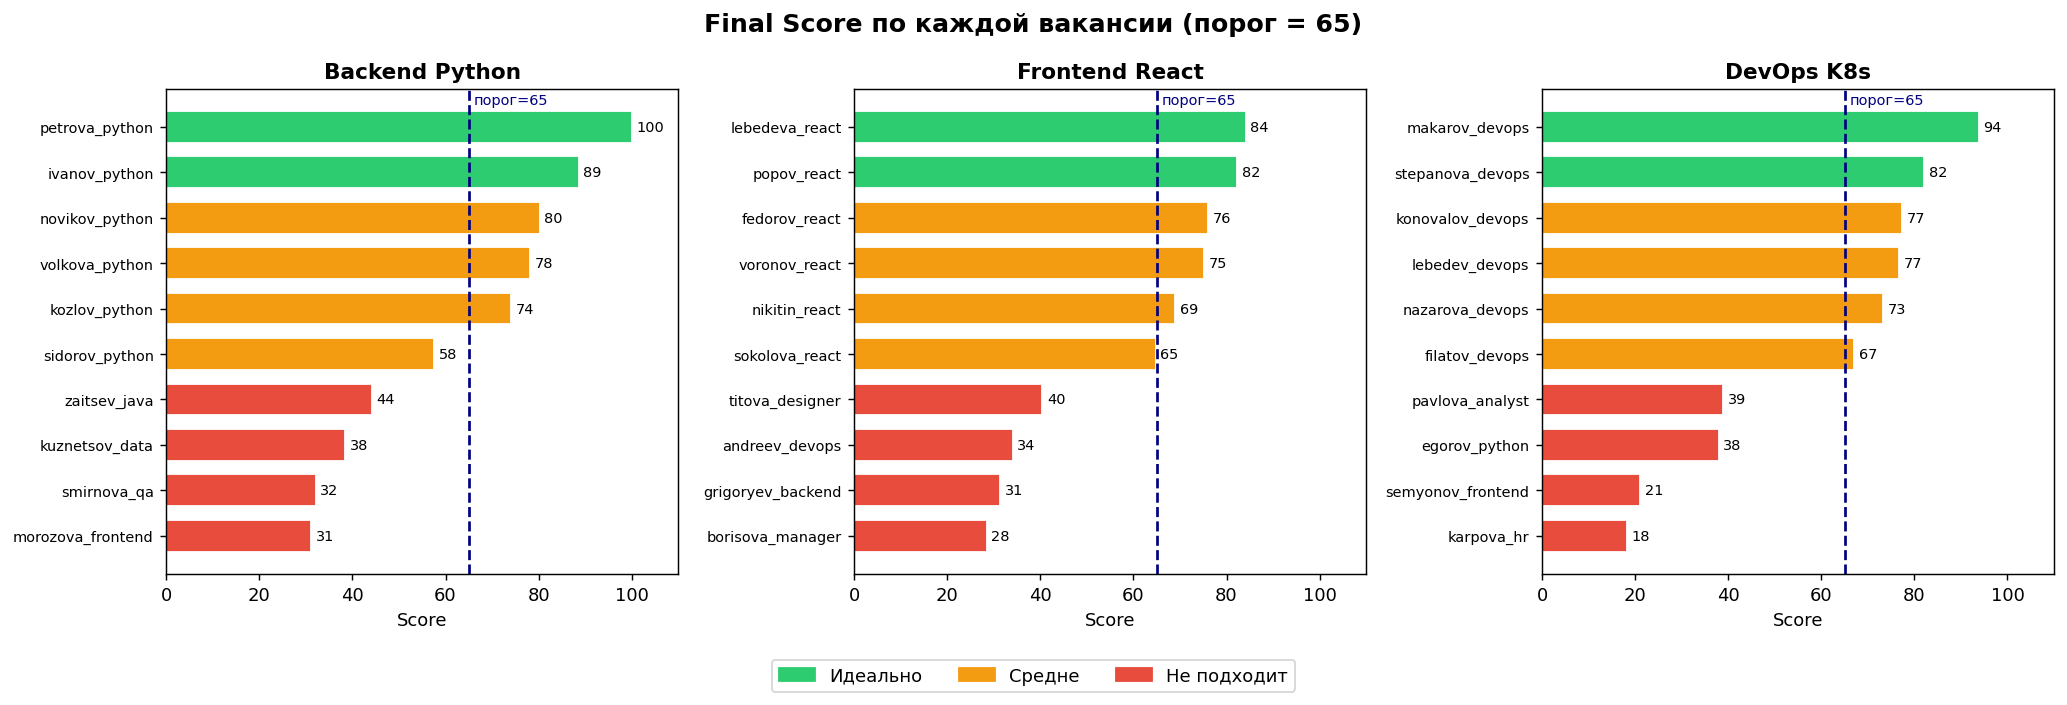

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

plt.rcParams['figure.dpi'] = 130

COLORS     = {'ideal': '#2ecc71', 'medium': '#f39c12', 'miss': '#e74c3c'}
LABELS_RU  = {'ideal': 'Идеально', 'medium': 'Средне', 'miss': 'Не подходит'}
vacs       = df_ok['vacancy'].unique()
leg_patches = [mpatches.Patch(color=c, label=LABELS_RU[l]) for l, c in COLORS.items()]

# ── График 1: Final Score по каждой вакансии + линия порога ─────────
fig, axes = plt.subplots(1, len(vacs), figsize=(16, 5))
fig.suptitle(f'Final Score по каждой вакансии (порог = {THRESHOLD})', fontsize=14, fontweight='bold')

for ax, vac in zip(axes, vacs):
    vdf = df_ok[df_ok['vacancy'] == vac].sort_values('final_score')
    colors = [COLORS[l] for l in vdf['label']]
    names  = [r.split('_', 2)[-1][:22] for r in vdf['resume']]
    bars   = ax.barh(range(len(vdf)), vdf['final_score'], color=colors, edgecolor='white', height=0.7)
    ax.set_yticks(range(len(vdf)))
    ax.set_yticklabels(names, fontsize=8)
    ax.set_xlim(0, 110)
    ax.set_xlabel('Score')
    ax.set_title(VAC_NAMES.get(vac, vac), fontweight='bold')
    # Линия порога
    ax.axvline(THRESHOLD, color='navy', linestyle='--', linewidth=1.5, label=f'Порог {THRESHOLD}')
    ax.text(THRESHOLD + 1, len(vdf) - 0.5, f'порог={THRESHOLD}', color='navy', fontsize=8)
    for bar, score in zip(bars, vdf['final_score']):
        ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
                f'{score:.0f}', va='center', fontsize=8)

fig.legend(handles=leg_patches, loc='lower center', ncol=3, bbox_to_anchor=(0.5, -0.08))
plt.tight_layout()
plt.savefig('chart1_final_scores.png', bbox_inches='tight')
plt.show()

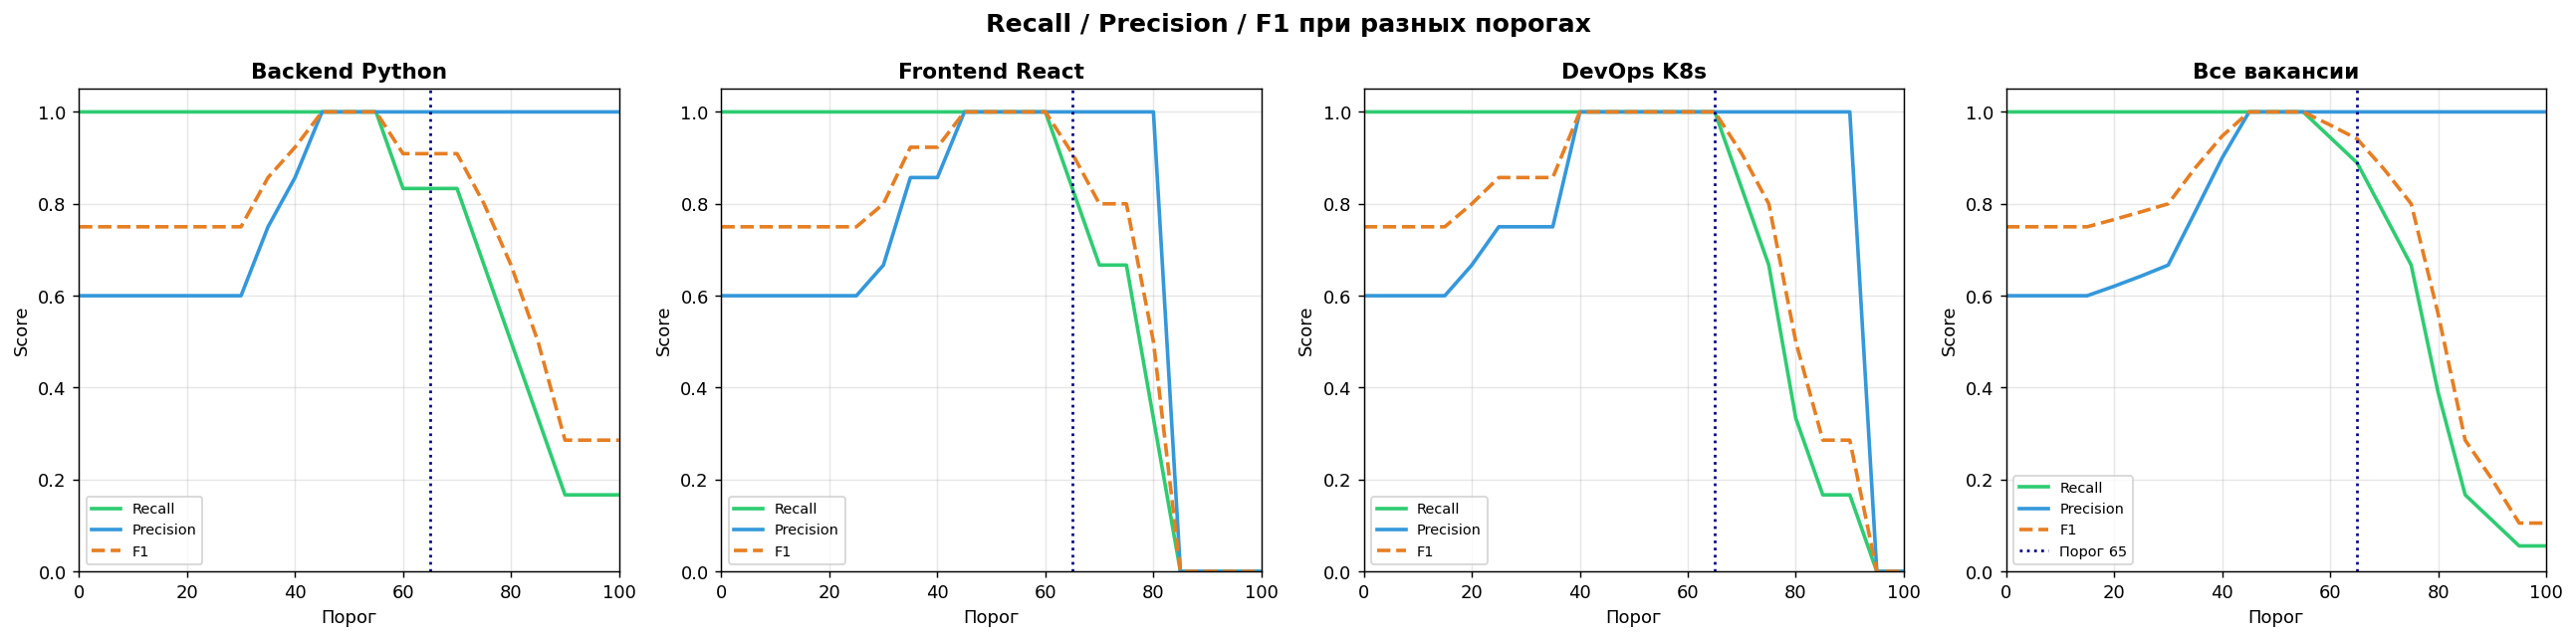

In [ ]:
# ── График 2: Recall, Precision, F1 при разных порогах ──────────────
thresholds = np.arange(0, 101, 5)

fig, axes = plt.subplots(1, len(vacs) + 1, figsize=(20, 5))
fig.suptitle('Recall / Precision / F1 при разных порогах', fontsize=14, fontweight='bold')

def metrics_at_thresholds(sub_df):
    recs, precs, f1s = [], [], []
    yt = sub_df['y_true']
    for t in thresholds:
        yp = (sub_df['final_score'] >= t).astype(int)
        recs.append(recall_score(yt, yp, zero_division=0))
        precs.append(precision_score(yt, yp, zero_division=0))
        f1s.append(f1_score(yt, yp, zero_division=0))
    return recs, precs, f1s

# По каждой вакансии
for ax, vac in zip(axes[:-1], vacs):
    vdf = df_ok[df_ok['vacancy'] == vac]
    recs, precs, f1s = metrics_at_thresholds(vdf)
    ax.plot(thresholds, recs,  label='Recall',    color='#2ecc71', linewidth=2)
    ax.plot(thresholds, precs, label='Precision', color='#3498db', linewidth=2)
    ax.plot(thresholds, f1s,   label='F1',        color='#e67e22', linewidth=2, linestyle='--')
    ax.axvline(THRESHOLD, color='navy', linestyle=':', linewidth=1.5)
    ax.set_title(VAC_NAMES.get(vac, vac), fontweight='bold')
    ax.set_xlabel('Порог'); ax.set_ylabel('Score')
    ax.set_ylim(0, 1.05); ax.set_xlim(0, 100)
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

# Общий
recs, precs, f1s = metrics_at_thresholds(df_ok)
ax = axes[-1]
ax.plot(thresholds, recs,  label='Recall',    color='#2ecc71', linewidth=2)
ax.plot(thresholds, precs, label='Precision', color='#3498db', linewidth=2)
ax.plot(thresholds, f1s,   label='F1',        color='#e67e22', linewidth=2, linestyle='--')
ax.axvline(THRESHOLD, color='navy', linestyle=':', linewidth=1.5, label=f'Порог {THRESHOLD}')
ax.set_title('Все вакансии', fontweight='bold')
ax.set_xlabel('Порог'); ax.set_ylabel('Score')
ax.set_ylim(0, 1.05); ax.set_xlim(0, 100)
ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('chart2_recall_precision_f1.png', bbox_inches='tight')
plt.show()

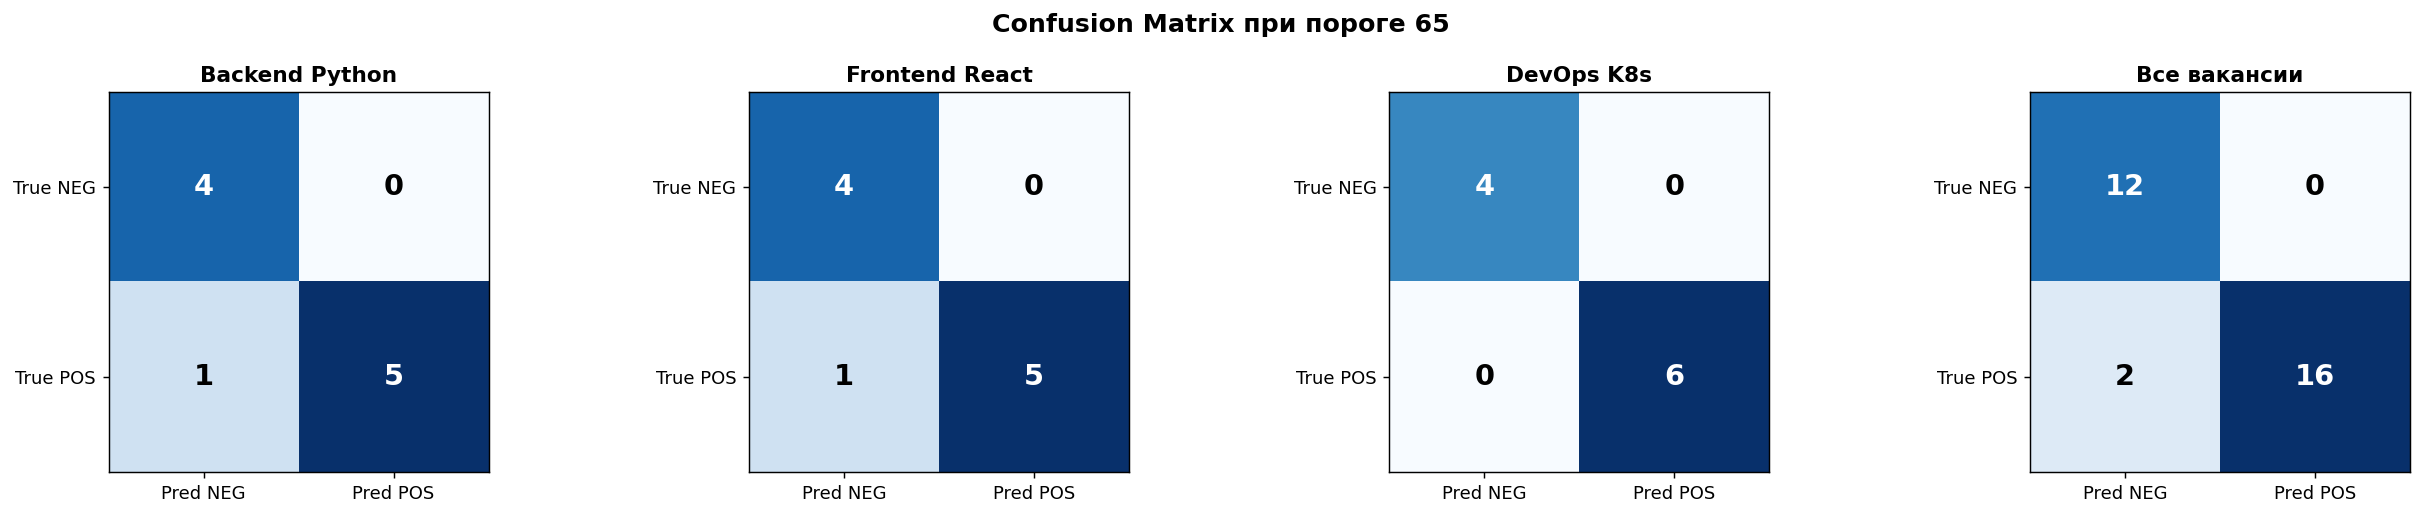

In [ ]:
# ── График 3: Confusion Matrix при пороге 80 ────────────────────────
import matplotlib.ticker as ticker

fig, axes = plt.subplots(1, len(vacs) + 1, figsize=(20, 4))
fig.suptitle(f'Confusion Matrix при пороге {THRESHOLD}', fontsize=14, fontweight='bold')

def plot_cm(ax, yt, yp, title):
    cm = confusion_matrix(yt, yp)
    im = ax.imshow(cm, cmap='Blues')
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(['Pred NEG', 'Pred POS'])
    ax.set_yticklabels(['True NEG', 'True POS'])
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm[i, j]), ha='center', va='center',
                    fontsize=16, fontweight='bold',
                    color='white' if cm[i, j] > cm.max()/2 else 'black')
    ax.set_title(title, fontweight='bold')

for ax, vac in zip(axes[:-1], vacs):
    vdf = df_ok[df_ok['vacancy'] == vac]
    plot_cm(ax, vdf['y_true'], vdf['y_pred'], VAC_NAMES.get(vac, vac))

plot_cm(axes[-1], df_ok['y_true'], df_ok['y_pred'], 'Все вакансии')
plt.tight_layout()
plt.savefig('chart3_confusion_matrix.png', bbox_inches='tight')
plt.show()

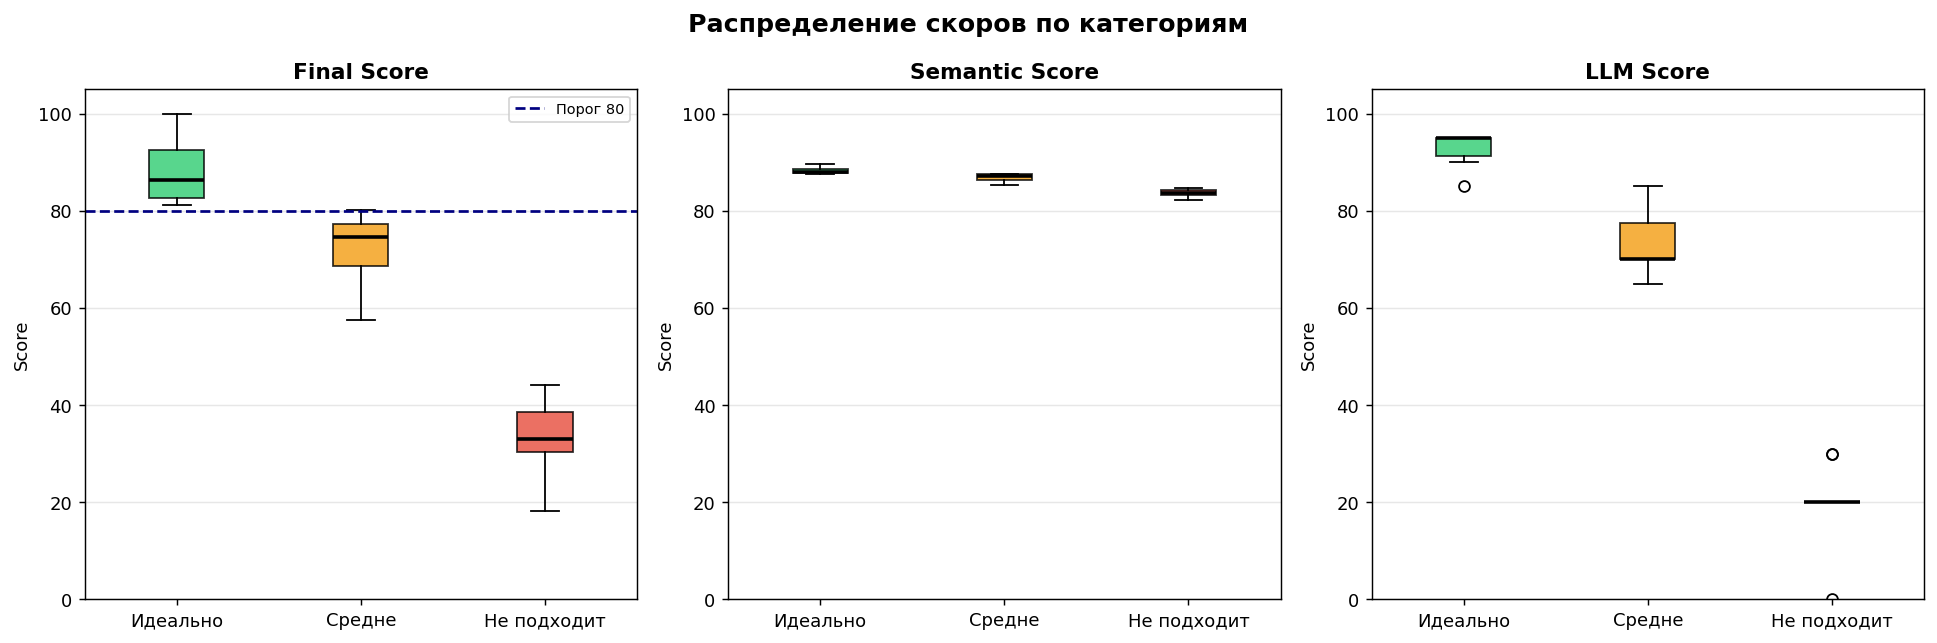

In [ ]:
# ── График 4: Box plot — распределение скоров по категориям ─────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Распределение скоров по категориям', fontsize=14, fontweight='bold')

for ax, (col, title) in zip(axes, [('final_score','Final Score'),
                                     ('semantic_score','Semantic Score'),
                                     ('llm_score','LLM Score')]):
    data = [df_ok[df_ok['label']==l][col].dropna().values for l in ['ideal','medium','miss']]
    bp = ax.boxplot(data, patch_artist=True, medianprops={'color':'black','linewidth':2})
    for patch, lbl in zip(bp['boxes'], ['ideal','medium','miss']):
        patch.set_facecolor(COLORS[lbl]); patch.set_alpha(0.8)
    ax.set_xticks([1,2,3])
    ax.set_xticklabels([LABELS_RU[l] for l in ['ideal','medium','miss']])
    if col == 'final_score':
        ax.axhline(THRESHOLD, color='navy', linestyle='--', linewidth=1.5, label=f'Порог {THRESHOLD}')
        ax.legend(fontsize=8)
    ax.set_ylim(0, 105); ax.set_ylabel('Score')
    ax.set_title(title, fontweight='bold'); ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('chart4_boxplots.png', bbox_inches='tight')
plt.show()

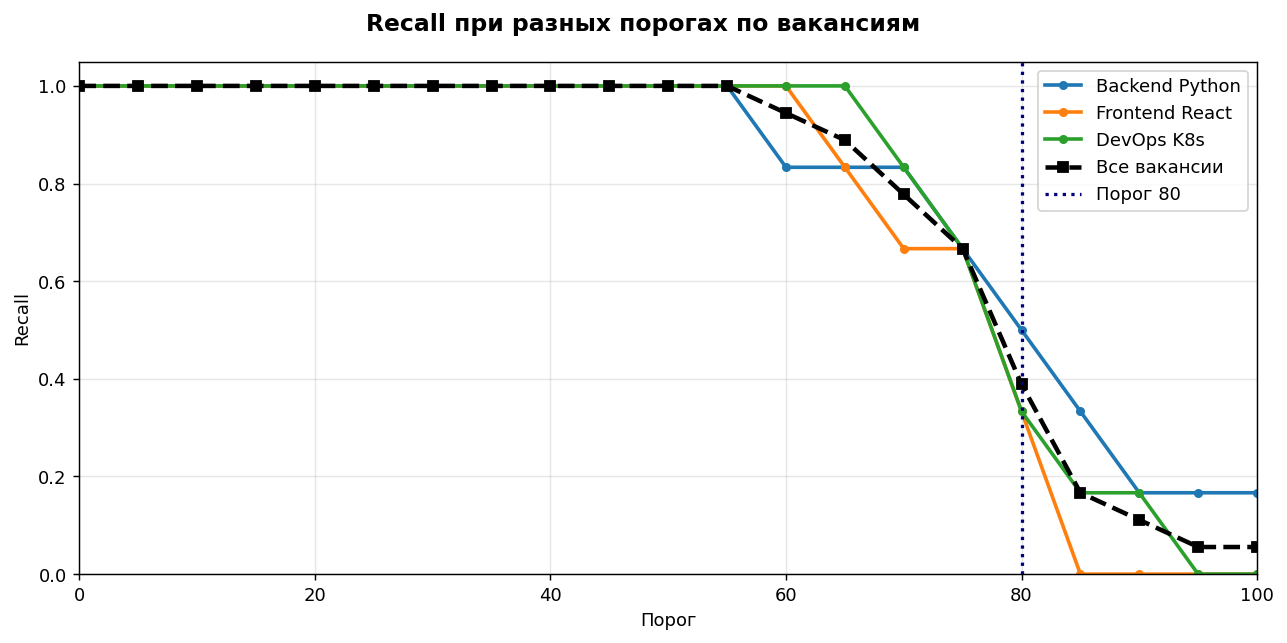

In [ ]:
# ── График 5: Recall @ разные пороги по вакансиям ───────────────────
fig, ax = plt.subplots(figsize=(10, 5))
fig.suptitle('Recall при разных порогах по вакансиям', fontsize=13, fontweight='bold')

for vac in vacs:
    vdf = df_ok[df_ok['vacancy'] == vac]
    yt = vdf['y_true']
    recalls = [recall_score(yt, (vdf['final_score'] >= t).astype(int), zero_division=0)
               for t in thresholds]
    ax.plot(thresholds, recalls, marker='o', markersize=4,
            label=VAC_NAMES.get(vac, vac), linewidth=2)

# Общий
recalls_all = [recall_score(df_ok['y_true'],
                            (df_ok['final_score'] >= t).astype(int), zero_division=0)
               for t in thresholds]
ax.plot(thresholds, recalls_all, marker='s', markersize=5, label='Все вакансии',
        linewidth=2.5, linestyle='--', color='black')

ax.axvline(THRESHOLD, color='navy', linestyle=':', linewidth=1.8, label=f'Порог {THRESHOLD}')
ax.set_xlabel('Порог'); ax.set_ylabel('Recall')
ax.set_ylim(0, 1.05); ax.set_xlim(0, 100)
ax.grid(alpha=0.3); ax.legend()
plt.tight_layout()
plt.savefig('chart5_recall.png', bbox_inches='tight')
plt.show()

## Шаг 8 — Итоговая таблица и скачивание

In [ ]:
from google.colab import files

# Сводная таблица
summary = df_ok.groupby('label').agg(
    count=('final_score','count'),
    final_mean=('final_score','mean'),
    semantic_mean=('semantic_score','mean'),
    llm_mean=('llm_score','mean'),
    above_threshold=('y_pred','sum'),
).round(2)
summary.index = [LABELS_RU[i] for i in summary.index]
summary['above_threshold'] = summary['above_threshold'].astype(int)
print(f'=== Сводная таблица (порог={THRESHOLD}) ===')
print(summary.to_string())
print(f'\nRecall={recall:.3f}  Precision={precision:.3f}  F1={f1:.3f}  ROC-AUC={auc:.3f}')

df.to_csv('results.csv', index=False)
metrics_df.to_csv('metrics.csv')
print('\nСохранено results.csv, metrics.csv')

for fname in ['results.csv', 'metrics.csv',
              'chart1_final_scores.png', 'chart2_recall_precision_f1.png',
              'chart3_confusion_matrix.png', 'chart4_boxplots.png', 'chart5_recall.png']:
    if os.path.exists(fname):
        files.download(fname)
        print(f'Скачано: {fname}')

=== Сводная таблица (порог=80) ===
             count  final_mean  semantic_mean  llm_mean  above_threshold
Идеально         6       88.30          88.27     92.50                6
Средне          12       72.53          86.91     74.17                1
Не подходит     12       33.00          83.63     20.00                0

Recall=0.389  Precision=1.000  F1=0.560  ROC-AUC=1.000

Сохранено results.csv, metrics.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Скачано: results.csv


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

Скачано: chart4_boxplots.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Скачано: chart5_recall.png
